
# LLM Router — Unified Log Loader
This notebook loads and indexes experiment runs with the unified filenames:
- `metrics.jsonl`
- `output.jsonl`
- `queue.json` (optional)
- `results.json`

It assumes your repo layout like:
```
results/
  rr-batching/
    17/
      metrics.jsonl
      output.jsonl
      queue.json
      results.json
  pull-batching/
    29/
      metrics.jsonl
      output.jsonl
      queue.json
      results.json
...
```

> **Tip:** You can change `BASE_DIR` below if your results are elsewhere.


In [49]:
import pandas as pd


from utils_analysis import (
    load_experiment,
    make_runs_index,
    normalize_metrics_samples,
    collect_results_summary,
    collect_all_metrics,
    collect_all_outputs,
    select_metrics,
    metrics_to_endpoint_tables,
    summarize_output_metric,
    draw_output_time_each,
    collect_all_queues,
    summarize_metrics_metric,
    summarize_queue_metric,
    cumulative_output_metric,
    cumulative_metrics_metric,
    cumulative_queue_metric,
    list_available_metrics_metrics,
    list_available_output_metrics,
    list_all_metrics_for_run,
    draw_violin_for_metric,
    draw_token_length_distribution_per_endpoint,
    build_tokens_by_endpoint,
    summarize_by_endpoint,
    plot_ecdf_per_method,
    plot_violins_per_method
)


BASE_DIR = "/home/saeid/llm-lb/results"  # or "results copy"
SERIES = "205"

SERIES_1 = "206"

# Put only the experiments you want to analyze here:
EXPERIMENTS = [
    # ("rr-batching", "178"),
    # ("rr-batching", "179"),
    # ("rr-batching", "180"),
    # ("rr-batching", "181"),
    # ("rr-batching", "182"),
    # ("least-queue-batching", SERIES),
    # ("rr-batching", SERIES),
    ("pull-batching", SERIES),
    ("pull-batching", SERIES_1),
    # ("least-queue-batching", "91"),
    # ("least-queue-batching", "92"),
    # ("least-queue-batching", "93"),
    # ("rr-batching", SERIES),
    # ("least-queue-batching", SERIES),
    # ("pull-batching", SERIES),
    # ("least-queue-batching", "6"),
    # ("random-batching", "5"),
    # ("pull", "5"),
    # ("least-queue-worker", "2"),
    # ("pull-batching", "40"),
    # ("least-queue-batching", "14"),
]

runs_index = make_runs_index(EXPERIMENTS, base_dir=BASE_DIR)
# runs_index

In [50]:
method, run_id = runs_index.iloc[0][["method", "run_id"]]
exp = load_experiment(method, run_id, base_dir=BASE_DIR)

# print("Loaded sections:", list(exp.keys()))
# if "results" in exp:
#     print("results.json:", exp["results"])

# Peek at raw frames
# display(exp.get("metrics", pd.DataFrame()).head())
# display(exp.get("output", pd.DataFrame()).head())
# display(exp.get("queue", pd.DataFrame()).head())

# Normalize metrics.samples for this run
metrics_norm = normalize_metrics_samples(
    exp.get("metrics", pd.DataFrame()), method, run_id
)
print("Normalized metrics shape:", metrics_norm.shape)
# display(metrics_norm.head())

Normalized metrics shape: (696, 31)


In [51]:
results_summary = collect_results_summary(runs_index)
metrics_all = collect_all_metrics(runs_index)
outputs_all = collect_all_outputs(runs_index)
queues_all = collect_all_queues(runs_index)


# display(results_summary.head())
# display(metrics_all.head())
# display(outputs_all.head())

# Optional CSVs for quick offline inspection
# runs_index.to_csv("runs_index.csv", index=False)
# if not results_summary.empty:
#     results_summary.to_csv("results_summary_flat.csv", index=False)
# print("Exports written where available")
# outputs_all

In [52]:
queues_all.columns

Index(['ts', 'mode', 'endpoint', 'model', 'status', 'prompt', 'session_idx',
       'util_pct', 'want', 'pulled', 'inflight_before', 'inflight_after',
       'q_before', 'q_after', 'every_n', 'len_aware', 'len_policy',
       'pool_factor', 'kv_aware', 'kv_priority_policy', 'kv_route_mode',
       'method', 'run_id'],
      dtype='object')

In [53]:
# Examples (uncomment and adjust as needed):

# 1) Filter rows by one endpoint and one mode; select specific columns
# sel = select_metrics(
#     metrics_all,
#     endpoints="10.1.62.151:8200",
#     modes="rr-batching",
#     experiments=None,  # or "17" or [("rr-batching","17")]
#     columns=["ts", "method", "run_id", "mode", "instance", "gen_tokens_per_sec", "gpu_util_percent"]
# )

# 2) Filter by multiple endpoints and experiments (run_ids), keep all columns
# sel = select_metrics(
#     metrics_all,
#     endpoints=["10.1.62.151:8200","10.1.62.162:8200"],
#     modes=None,
#     experiments=["17","29"]
# )

# 3) Filter by explicit (method, run_id) pairs
# sel = select_metrics(
#     metrics_all,
#     experiments=[("rr-batching","17"), ("pull-batching","29")],
#     columns=["ts","method","run_id","instance","requests_running","gen_tokens_per_sec"]
# )

# 4) Just column projection on all aggregated metrics
# sel = select_metrics(
#     metrics_all,
#     columns=["ts","instance","gen_tokens_per_sec","gpu_util_percent"]
# )

# Choose one of the above options or define your own:
sel = select_metrics(
    metrics_all,
    endpoints=["10.1.62.151:8200", "10.1.62.162:8200"],
    modes=f"{BASE_DIR}/rr-batching",
    experiments=SERIES,
    columns=[
        "ts",
        "method",
        "run_id",
        "mode",
        "instance",
        "gen_tokens_per_sec",
        "gpu_util_percent",
    ],
)

display(sel.head())
print("Rows:", len(sel), "| Columns:", list(sel.columns))

,ts,method,run_id,mode,instance,gen_tokens_per_sec,gpu_util_percent


Rows: 0 | Columns: ['ts', 'method', 'run_id', 'mode', 'instance', 'gen_tokens_per_sec', 'gpu_util_percent']


In [54]:
# Assume you have metrics_all or metrics_norm
df_metrics = metrics_all if not metrics_all.empty else metrics_norm

endpoint_tables = metrics_to_endpoint_tables(df_metrics)
# print("Endpoints:", list(endpoint_tables.keys()))
try:
    # Example: access by endpoint
    ep = list(endpoint_tables.keys())[0]
    df_ep = endpoint_tables[ep]
    # print("First endpoint:", ep)
    # display(df_ep.head())

    # Loop over all endpoints
    # for ep, df_ep in endpoint_tables.items():
    #     print(f"\nEndpoint: {ep}, rows={len(df_ep)}")
    #     display(df_ep.head(2))
except:
    print("test")

def collect_all_queues(runs_index):
    frames = []
    for _, row in runs_index.iterrows():
        if row["queue_path"]:
            df = read_queue(row["queue_path"])
            df["method"] = row["method"]
            df["run_id"] = row["run_id"]
            frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

queues_all = collect_all_queues(runs_index)
queues_all.head()


In [55]:
# Just numeric output metrics (with derived) for run 42
list_available_output_metrics("rr-batching", "95", base_dir=BASE_DIR)

[]

In [56]:
# [
#   "latency_s",
#   "router_queue_wait",
#   "server_roundtrip",
#   "end_to_end_latency",
#   "measured_router_queue_wait",
#   "measured_server_roundtrip",
#   "measured_end_to_end_latency",
#   "predicted_out_tokens",
#   "actual_out_tokens",
# ]

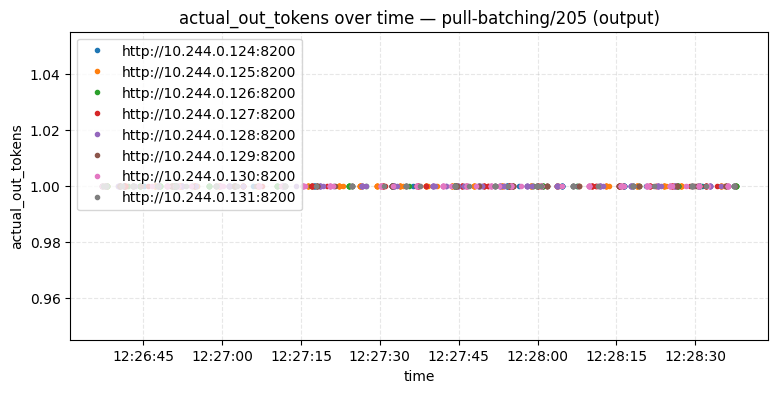

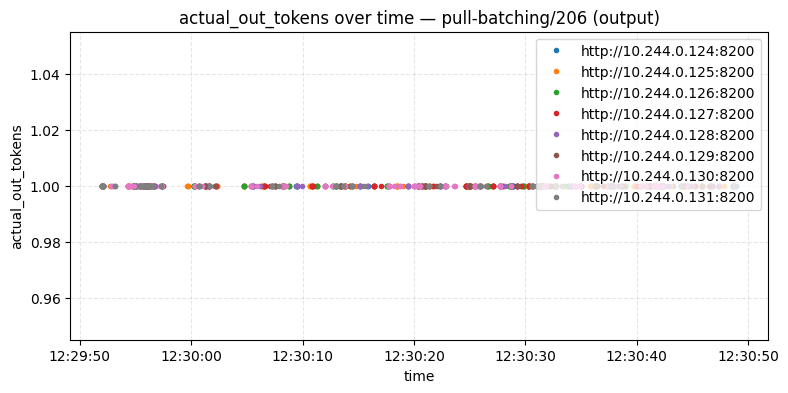

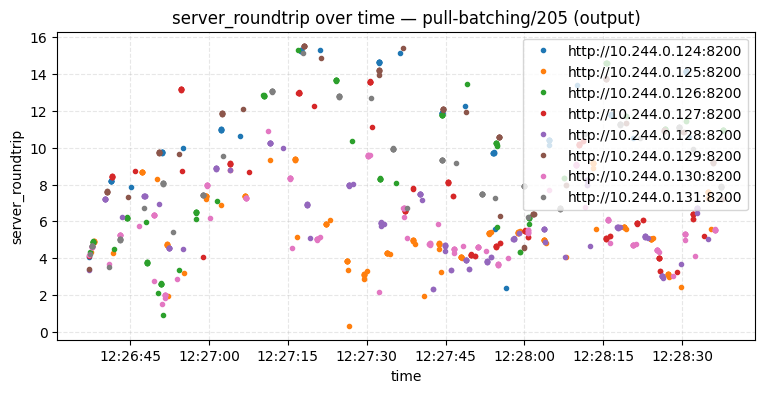

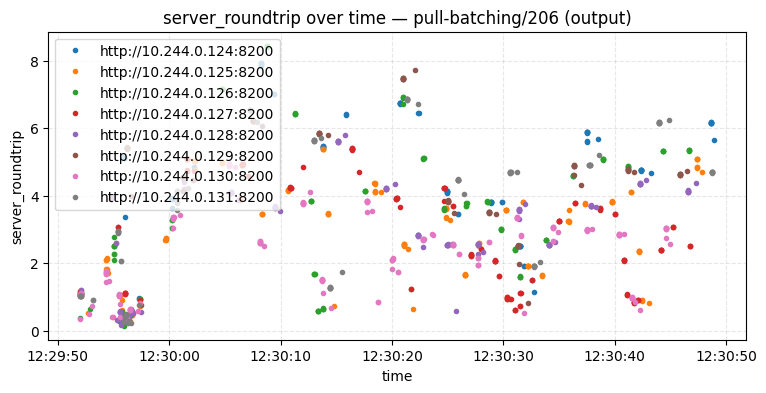

In [57]:
# 2) output.jsonl — latency per request (points), separate figures
['latency_s',
 'req_id',
 't_arrival_router',
 't_dispatch_router',
 't_response_router',
 'router_queue_wait',
 'server_roundtrip',
 'end_to_end_latency',
 'measured_router_queue_wait',
 'measured_server_roundtrip',
 'measured_end_to_end_latency',
 'input_tokens',
 "predicted_out_tokens",
 "actual_out_tokens",
 "total_predicted_tokens",
 "total_actual_tokens",
 ]

draw_output_time_each(
    EXPERIMENTS,
    metric="actual_out_tokens",
    endpoints=None,
    base_dir=BASE_DIR,
    per_request=True,  # raw events; resample ignored
    resample=None,
    title=None,
    save_path_template=None,
    # ylim=(0, 0.12),
)

draw_output_time_each(
    EXPERIMENTS,
    metric="server_roundtrip",
    endpoints=None,
    base_dir=BASE_DIR,
    per_request=True,  # raw events; resample ignored
    resample=None,
    title=None,
    save_path_template=None,
    # ylim=(0, 0.12),
)

In [58]:
# import matplotlib.pyplot as plt

# # Plot directly from your dataframe
# plt.figure(figsize=(8, 5))
# plt.bar(results_summary["method"], results_summary["runtime_sec"], color="skyblue")
# plt.xlabel("Method")
# plt.ylabel("Runtime (sec)")
# plt.title("Runtime by Batching Method")
# plt.xticks(rotation=15)
# plt.show()

In [59]:
# metric="sim_service_s"
metric = "server_roundtrip"

# least_queue_batching_df = summarize_output_metric(
#     "least-queue-batching",
#     SERIES,
#     metric=metric,
#     percentiles=(50, 90, 99),
#     base_dir=BASE_DIR,
#     include_overall=True,
# )

# rr_batching_df = summarize_output_metric(
#     "rr-batching",
#     SERIES,
#     metric=metric,
#     percentiles=(50, 90, 99),
#     base_dir=BASE_DIR,
#     include_overall=True,
# )

pull_batching_df_1 = summarize_output_metric(
    "pull-batching",
    SERIES,
    metric=metric,
    percentiles=(50, 90, 99),
    base_dir=BASE_DIR,
    include_overall=True,
)

pull_batching_df_2 = summarize_output_metric(
    "pull-batching",
    SERIES_1,
    metric=metric,
    percentiles=(50, 90, 99),
    base_dir=BASE_DIR,
    include_overall=True,
)

# # Save results into DataFrames
# pull_batching_df = summarize_output_metric(
#     "pull-batching",
#     SERIES,
#     metric=metric,
#     percentiles=(50, 90, 99),
#     base_dir=BASE_DIR,
#     include_overall=True,
# )

# least_queue_df = summarize_output_metric(
#     "least-queue-batching",
#     SERIES,
#     metric=metric,
#     percentiles=(50, 90, 99),
#     base_dir=BASE_DIR,
#     include_overall=True,
# )

# pull_batching_df = summarize_output_metric(
#     "pull-batching",
#     SERIES,
#     metric=metric,
#     percentiles=(50, 90, 99),
#     base_dir=BASE_DIR,
#     include_overall=True,
# )

# Display them
display(pull_batching_df_1)
display(pull_batching_df_2)
# display(pull_batching_df)

# rr_batching_df1 = summarize_output_metric(
#     "rr-batching",
#     "178",
#     metric=metric,
#     percentiles=(50, 90, 99),
#     base_dir=BASE_DIR,
#     include_overall=True,
# )

# rr_batching_df2 = summarize_output_metric(
#     "rr-batching",
#     "179",
#     metric=metric,
#     percentiles=(50, 90, 99),
#     base_dir=BASE_DIR,
#     include_overall=True,
# )

# rr_batching_df3 = summarize_output_metric(
#     "rr-batching",
#     "180",
#     metric=metric,
#     percentiles=(50, 90, 99),
#     base_dir=BASE_DIR,
#     include_overall=True,
# )

# rr_batching_df4 = summarize_output_metric(
#     "rr-batching",
#     "181",
#     metric=metric,
#     percentiles=(50, 90, 99),
#     base_dir=BASE_DIR,
#     include_overall=True,
# )

# # rr_batching_df4 = summarize_output_metric(
# #     "rr-batching",
# #     "182",
# #     metric=metric,
# #     percentiles=(50, 90, 99),
# #     base_dir=BASE_DIR,
# #     include_overall=True,
# # )

# display(rr_batching_df1)
# display(rr_batching_df2)
# display(rr_batching_df3)
# display(rr_batching_df4)

,endpoint,count,sum,mean,std,min,max,p50,p90,p99
0,http://10.244.0.124:8200,82,935.263524,11.405653,2.659519,2.355400,15.303825,11.005970,15.076788,15.293112
1,http://10.244.0.125:8200,174,958.813132,5.510420,1.877965,0.331092,9.396660,5.037590,8.698209,9.379242
2,http://10.244.0.126:8200,114,974.137906,8.545069,3.791157,0.933770,15.299119,8.323595,13.658420,14.622271
3,http://10.244.0.127:8200,123,945.095758,7.683705,3.184993,3.276505,13.608225,6.582308,13.153752,13.594146
4,http://10.244.0.128:8200,157,948.978467,6.044449,1.919100,2.319287,10.283274,5.706860,8.465785,10.264288
5,http://10.244.0.129:8200,91,977.914923,10.746318,2.922066,3.399784,15.542500,10.926651,14.236220,15.541606
6,http://10.244.0.130:8200,171,967.084373,5.655464,1.882561,1.531710,10.936797,5.257879,8.366358,9.591549
7,http://10.244.0.131:8200,112,976.645822,8.720052,2.620713,3.542367,15.167369,7.990382,12.791270,13.075797
8,ALL,1024,7683.933906,7.503842,3.258347,0.331092,15.542500,6.776035,12.773591,15.289138


,endpoint,count,sum,mean,std,min,max,p50,p90,p99
0,http://10.244.0.124:8200,92,450.312734,4.894704,1.658043,0.951258,7.923346,5.107673,6.740080,7.919705
1,http://10.244.0.125:8200,150,426.274831,2.841832,1.450857,0.263506,5.395210,3.236963,4.850843,5.382013
2,http://10.244.0.126:8200,126,414.003019,3.285738,2.202213,0.145348,8.440143,3.046332,6.437846,8.428444
3,http://10.244.0.127:8200,147,419.678601,2.854956,1.517324,0.407150,5.401617,3.074224,4.924953,5.394765
4,http://10.244.0.128:8200,133,424.291738,3.190163,1.397800,0.177155,5.808727,3.656811,4.368314,5.617061
5,http://10.244.0.129:8200,91,427.872766,4.701899,1.486209,0.770995,7.730860,4.712503,6.221855,7.504424
6,http://10.244.0.130:8200,170,400.580420,2.356355,1.160116,0.304763,4.936535,2.606788,3.788111,4.934729
7,http://10.244.0.131:8200,115,440.157549,3.827457,2.119454,0.215749,6.864757,4.471424,6.533018,6.863533
8,ALL,1024,3403.171658,3.323410,1.812379,0.145348,8.440143,3.470212,5.631926,7.672993


In [60]:
# # ========================================
# # 3) router output.jsonl — token-length distributions per endpoint
# # ========================================

# # Outgoing tokens per endpoint
# # draw_token_length_distribution_per_endpoint(
# #     "least-queue-batching", SERIES,
# #     token_col="actual_out_tokens",
# #     endpoints=None,
# #     base_dir=BASE_DIR,
# #     bins=20,
# #     density=False,
# #     title_prefix="Token length distribution (router)",
# # )

# # draw_token_length_distribution_per_endpoint(
# #     "rr-batching", SERIES,
# #     token_col="actual_out_tokens",
# #     endpoints=None,
# #     base_dir=BASE_DIR,
# #     bins=20,
# #     density=False,
# #     title_prefix="Token length distribution (router)",
# # )

# draw_token_length_distribution_per_endpoint(
#     "pull-batching", SERIES,
#     token_col="actual_out_tokens",
#     endpoints=None,
#     base_dir=BASE_DIR,
#     bins=20,
#     density=False,
#     title_prefix="Token length distribution (router)",
# )

# draw_token_length_distribution_per_endpoint(
#     "pull-batching", SERIES_1,
#     token_col="actual_out_tokens",
#     endpoints=None,
#     base_dir=BASE_DIR,
#     bins=20,
#     density=False,
#     title_prefix="Token length distribution (router)",
# )


Collected 2,048 rows across 8 endpoints.


,method,run_id,endpoint,token
0,pull-batching,205,http://10.244.0.128:8200,342
1,pull-batching,205,http://10.244.0.127:8200,342
2,pull-batching,205,http://10.244.0.124:8200,342
3,pull-batching,205,http://10.244.0.129:8200,342
4,pull-batching,205,http://10.244.0.130:8200,511


,method,run_id,endpoint,count,mean,std,min,max,p50,p90,p95,p99
0,pull-batching,205,http://10.244.0.124:8200,82,476.451220,181.555226,307.0,856.0,395.5,741.0,856.0,856.00
1,pull-batching,205,http://10.244.0.125:8200,174,431.362069,125.224381,256.0,856.0,392.0,549.7,719.0,771.00
2,pull-batching,205,http://10.244.0.126:8200,114,462.052632,120.956354,256.0,856.0,499.0,550.0,691.0,771.00
3,pull-batching,205,http://10.244.0.127:8200,123,481.463415,157.326813,294.0,856.0,453.0,731.0,847.5,856.00
4,pull-batching,205,http://10.244.0.128:8200,157,462.566879,174.688928,256.0,856.0,392.0,741.0,771.0,856.00
5,pull-batching,205,http://10.244.0.129:8200,91,521.230769,174.458723,256.0,856.0,513.0,741.0,856.0,856.00
6,pull-batching,205,http://10.244.0.130:8200,171,453.526316,126.920416,256.0,856.0,448.0,572.0,691.0,750.00
7,pull-batching,205,http://10.244.0.131:8200,112,459.321429,132.400172,256.0,856.0,467.5,550.0,771.0,771.00
8,pull-batching,206,http://10.244.0.124:8200,92,432.739130,142.102105,307.0,856.0,369.0,741.0,741.0,778.65
9,pull-batching,206,http://10.244.0.125:8200,150,428.186667,122.490180,256.0,771.0,392.0,550.0,648.0,771.00


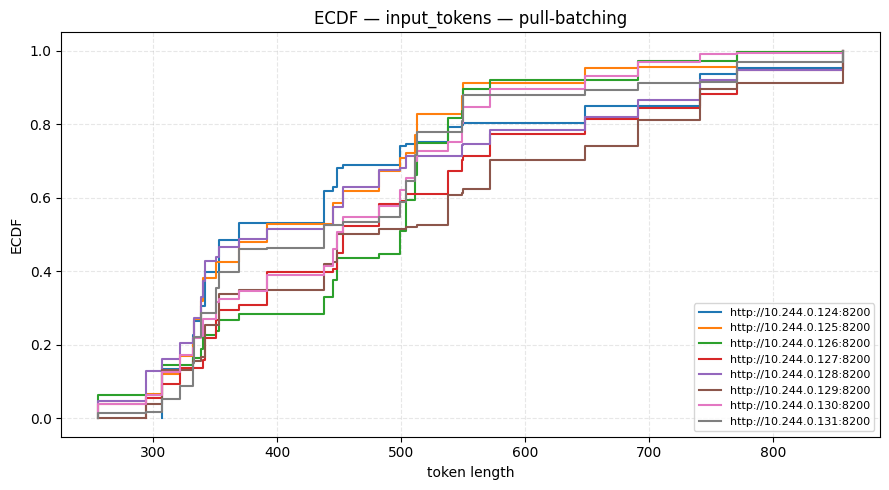

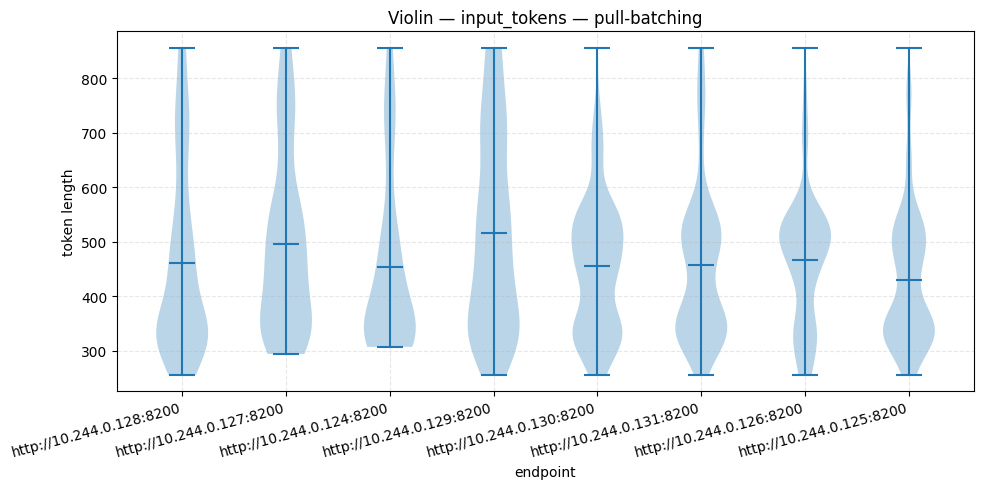

In [61]:
# ========================================
# Compare token-length distributions across endpoints per experiment
# ========================================

TOKEN_COL = "input_tokens"
ENDPOINTS_FILTER = None  # or ["http://10.244.0.51:8200"]

tokens_ep = build_tokens_by_endpoint(
    experiments=EXPERIMENTS,
    base_dir=BASE_DIR,
    token_col=TOKEN_COL,
    endpoints=ENDPOINTS_FILTER,
)

print(f"Collected {len(tokens_ep):,} rows across {tokens_ep['endpoint'].nunique()} endpoints.")
display(tokens_ep.head())

endpoint_summary = summarize_by_endpoint(tokens_ep)
display(endpoint_summary)

plot_ecdf_per_method(tokens_ep, title_prefix=f"ECDF — {TOKEN_COL}")
plot_violins_per_method(tokens_ep, title_prefix=f"Violin — {TOKEN_COL}")


In [62]:
# draw_violin_for_metric(
#     {
#         "rr-batching": rr_batching_df,
#         "least-queue-batching": least_queue_df,
#         "pull-batching": pull_batching_df
#     },
#     value_col="p99",        # or "mean", "p50", "p90"
#     group_col="endpoint",
#     drop_overall=True,
#     title="Latency (p99) by strategy"
# )

In [63]:
# # Show full responses + response length grouped by prompt

# df_long = outputs_all[
#     ["prompt", "run_id", "method", "response_preview", "latency_s"]
# ].copy()

# # Add response length
# df_long["resp_len"] = df_long["response_preview"].astype(str).str.len()

# # Sort for readability
# df_long = df_long.sort_values(["prompt", "run_id"]).reset_index(drop=True)

# pd.set_option("display.max_colwidth", None)

# for prompt, group in df_long.groupby("prompt"):
#     print("=" * 120)
#     print(f"Prompt: {prompt}\n")
#     for _, row in group.iterrows():
#         label = f"{row['method']}/{row['run_id']} | latency={row['latency_s']:.2f}s | length={row['resp_len']}"
#         print(f"[{label}]\n{row['response_preview']}\n")

In [64]:
# print(outputs_all.columns)
# # Add a column with the length of each response_preview string
# outputs_all["prompt_len"] = outputs_all["response_preview"].fillna("").apply(len)

# print(outputs_all[["run_id", "mode", "prompt_len"]])

In [65]:
# # 2) output.jsonl — latency per request (points), separate figures
# draw_output_time_each(
#     EXPERIMENTS,
#     metric="sim_queue_wait_s",
#     endpoints=None,
#     base_dir=BASE_DIR,
#     per_request=True,  # raw events; resample ignored
#     resample=None,
#     title=None,
#     save_path_template=None,
#     ylim=None
# )

In [66]:
# # 2) output.jsonl — latency per request (points), separate figures
# draw_output_time_each(
#     EXPERIMENTS,
#     metric="sim_service_s",
#     endpoints=None,
#     base_dir=BASE_DIR,
#     per_request=True,  # raw events; resample ignored
#     resample=None,
#     title=None,
#     save_path_template=None,
#     ylim=None
# )

In [67]:
# import pandas as pd

# outputs_all = outputs_all.copy()

# # Reset exp_local_id inside each (run_id, mode)
# outputs_all["exp_local_id"] = outputs_all.groupby(["run_id", "mode"]).cumcount()

# def print_orders_only(df: pd.DataFrame, use_col: str = "exp_local_id"):
#     for (rid, mode), g in df.groupby(["run_id", "mode"], dropna=False, sort=True):
#         g = g.reset_index(drop=True)

#         gen  = g.sort_values(["t_enq_client_s",  "exp_local_id"])
#         sent = g.sort_values(["t_send_http_s",   "exp_local_id"])
#         recv = g.sort_values(["t_recv_http_s",   "exp_local_id"])

#         gen_order  = gen[use_col].tolist()
#         sent_order = sent[use_col].tolist()
#         recv_order = recv[use_col].tolist()

#         print("\n" + "="*80)
#         print(f"=== Experiment: run_id={rid}, mode={mode} ===")
#         print(f"- Generation order ({use_col}):")
#         print(gen_order)
#         print(f"- Sent order ({use_col}):")
#         print(sent_order)
#         print(f"- Received order ({use_col}):")
#         print(recv_order)
#         print("- Checks:")
#         print(f"  gen == sent ? {gen_order == sent_order}")
#         print(f"  gen == recv ? {gen_order == recv_order}")
#         print(f"  sent == recv ? {sent_order == recv_order}")
#         print("="*80)

# # run
# print_orders_only(outputs_all, use_col="exp_local_id")

In [68]:
# import numpy as np
# import pandas as pd

# # Show everything without truncation
# pd.set_option("display.max_rows", None)
# pd.set_option("display.max_columns", None)
# pd.set_option("display.width", 0)
# pd.set_option("display.max_colwidth", None)

# # Ensure we have a length column (character count of response_preview)
# if "prompt_len" not in outputs_all.columns:
#     outputs_all["prompt_len"] = outputs_all["response_preview"].fillna("").apply(len)

# def analyze_and_print_group(g, key):
#     rid, mode = key
#     # Reset row_id starting from 0 per experiment
#     g = g.copy().reset_index(drop=True).rename_axis("row_id").reset_index()

#     # Add generation rank (based on enqueue time if available)
#     if "t_enq_client_s" in g.columns:
#         g["gen_rank"] = g["t_enq_client_s"].rank(method="first").astype(int)
#     else:
#         g["gen_rank"] = g["t_send_http_s"].rank(method="first").astype(int)

#     # Sort by generation / send / receive
#     gen  = g.sort_values(["gen_rank", "row_id"])
#     sent = g.sort_values(["t_send_http_s", "row_id"])
#     recv = g.sort_values(["t_recv_http_s", "row_id"])

#     # Orders (per-experiment row_id)
#     gen_order_ids  = gen["row_id"].tolist()
#     sent_order_ids = sent["row_id"].tolist()
#     recv_order_ids = recv["row_id"].tolist()

#     # Map: for each item in send order, where did it land in receive order?
#     recv_pos = {rid_: i for i, rid_ in enumerate(recv_order_ids)}
#     sent_to_recv_positions = [recv_pos[r] for r in sent_order_ids]

#     # Length sequences
#     sent_lengths = sent["prompt_len"].tolist()
#     recv_lengths = recv["prompt_len"].tolist()

#     # Per-row rank table
#     ranks = g[["row_id","t_enq_client_s","t_send_http_s","t_recv_http_s","prompt_len"]].copy()
#     ranks["gen_rank"]  = g["gen_rank"]
#     ranks["send_rank"] = g["t_send_http_s"].rank(method="first").astype(int)
#     ranks["recv_rank"] = g["t_recv_http_s"].rank(method="first").astype(int)

#     # ---- Print EVERYTHING for this experiment ----
#     print("\n" + "=" * 80)
#     print(f"=== Experiment: run_id={rid}, mode={mode} ===")
#     print("- Generation order (row_id):")
#     print(gen_order_ids)
#     print("- Sent order (row_id):")
#     print(sent_order_ids)
#     print("- Received order (row_id):")
#     print(recv_order_ids)
#     print("- Sent→Recv position map (index in recv order for each item in sent order):")
#     print(sent_to_recv_positions)
#     print("- Lengths in sent order (prompt_len):")
#     print(sent_lengths)
#     print("- Lengths in received order (prompt_len):")
#     print(recv_lengths)
#     print("- Per-row ranks (full):")
#     print(ranks.sort_values(["gen_rank","send_rank","recv_rank"]).to_string(index=False))
#     print("=" * 80 + "\n")

#     return {
#         "gen_order_ids": gen_order_ids,
#         "sent_order_ids": sent_order_ids,
#         "recv_order_ids": recv_order_ids,
#         "sent_to_recv_positions": sent_to_recv_positions,
#         "sent_lengths": sent_lengths,
#         "recv_lengths": recv_lengths,
#         "ranks_df": ranks.assign(run_id=rid, mode=mode)
#     }

# # Run for every (run_id, mode) experiment and print full details
# results = {}
# for key, grp in outputs_all.groupby(["run_id", "mode"], dropna=False):
#     results[key] = analyze_and_print_group(grp, key)

# # If you also want a single DataFrame with all rows from all experiments:
# all_ranks = pd.concat([v["ranks_df"] for v in results.values()], ignore_index=True)

# # Optional: save full per-experiment ranks to CSV if you want files later
# # all_ranks.to_csv("all_experiments_send_recv_ranks.csv", index=False)

In [69]:
# from utils_analysis import draw_metric_time

# method = "rr-batching"
# run_id = "9"
# metric = "requests_running"  # e.g., "gpu_util_percent", "gen_tokens_per_sec"
# endpoints = None  # or ["http://10.1.62.151:8200"]
# resample = None  # e.g., "1S" to bin by 1 second (mean)
# title = None
# save_to = None

# draw_metric_time(
#     method,
#     run_id,
#     metric,
#     endpoints=endpoints,
#     base_dir=BASE_DIR,
#     resample=resample,
#     title=title,
#     save_path=save_to,
# )

In [70]:
# from utils_analysis import draw_output_time

# method = "rr-batching"
# run_id = "9"
# metric = "latency_s"
# endpoints = None
# # When per_request=True, resample is ignored
# draw_output_time(
#     method,
#     run_id,
#     metric,
#     endpoints=endpoints,
#     base_dir=BASE_DIR,
#     resample=None,
#     per_request=True,  # raw per-request points
#     title=None,
#     save_path=None,
# )

In [71]:
# from utils_analysis import draw_output_time

# method = "rr-batching"
# run_id = "9"
# metric = "latency_s"  # request/event-driven; use mean when resampling
# endpoints = None
# resample = "1S"  # optional smoothing
# title = None
# save_to = None

# draw_output_time(
#     method,
#     run_id,
#     metric,
#     endpoints=endpoints,
#     base_dir=BASE_DIR,
#     resample=resample,
#     title=title,
#     save_path=save_to,
# )

In [72]:
# from utils_analysis import draw_queue_time

# method = "rr-batching"
# run_id = "10"
# metric = "inflight_after"  # state-driven; plotted as steps
# endpoints = None
# resample = "0.1S"  # optional; uses last+ffill per bin
# title = None
# save_to = None

# draw_queue_time(
#     method,
#     run_id,
#     metric,
#     endpoints=endpoints,
#     base_dir=BASE_DIR,
#     resample=resample,
#     title=title,
#     save_path=save_to,
# )